In [16]:
from frb.surveys import survey_utils as su

from astropy.coordinates import SkyCoord
from astropy import units as u, visualization as vis
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats

import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 16

from photutils.aperture import SkyEllipticalAperture

%matplotlib inline

# Looking for survey data at the FRB location

In [9]:
# Define the FRB coordinates
frb_coord = SkyCoord(334.019875, -7.89825, unit="deg")

# Define the error ellipse parameters
eellipse = {
        "a": 0.19, # a and b are in arcsec
        "a_sys": 0.33,
        "b": 0.18,
        "b_sys": 0.3,
        "cl": 68.0,
        "cl_sys": 68.0,
        "theta": 90.0, # PA is in degrees
        "theta_sys": 90.0
    }

# Net ellipse uncertainty
a_err = np.sqrt(eellipse['a']**2 + eellipse['a_sys']**2)*u.arcsec
b_err = np.sqrt(eellipse['b']**2 + eellipse['b_sys']**2)*u.arcsec
pa = 90*u.deg

Optical follow-up begins after the FRB localization is finalized. i.e. once a radio collaboration has settled on the centroid of the FRB and its localization region. Usually, for ~arcsec scale localizations, these are provided as ellipse axis lengths and position angle of the semi-major axis. We begin by looking if the FRB location is covered in any public optical survey.

## TODO: Add information here on how one can do this without the FRB repo

## Using the FRB repo

In [3]:
su.in_which_survey(frb_coord, optical_only=True)

/home/sunil/Python/FRB/frb/surveys/survey_utils.py:168: RuntimeWarning: Only 1 objects found in DESI within 1'. Check location manually.
  inside[surveyname] = is_inside(surveyname, coord)


{'Pan-STARRS': True,
 'WISE': True,
 'SDSS': True,
 'DES': False,
 'DESI': False,
 'DELVE': True,
 'DECaL': True,
 'VISTA': True,
 'NSC': True,
 'HSC': False,
 'NEDLVS': True}

Try to go with the deepest survey available at the location. In this case, it is DECaL: The DESI Legacy Survey.

In [4]:
# Load the survey class
survey = su.load_survey_by_name("DECaL", coord = frb_coord, radius = 20*u.arcsec)

# Download image source catalogs
cat = survey.get_catalog()
cat

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,DECaL_type
float64,float64,str4,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,str3
0.55565715,-99.0,-99.,0.40338215,1.1625718,0.29844,2.6116192,24.864761,0.17963151940691197,23.624924,0.14523489586765004,24.011751,0.30374839188409763,10995415891580592,334.0196233983205,-7.903334256162614,285734,REX
0.72559595,-99.0,-99.,0.47501132,1.4303143,0.20987336,2.5107749,25.122175,0.20318474722222302,24.672451,0.31759764053568584,26.16257,1.2212780200665088,10995415891580581,334.0193827938062,-7.90088807403465,285734,PSF
0.049984366,-99.0,-99.,0.017811825,0.10257448,0.013302397,0.17284901,21.781635,0.025701133101209663,21.77465,0.05617360376281625,21.81018,0.09807557693558246,10995415891580587,334.0194960779921,-7.899133149185396,285734,EXP
1.2153156,-99.0,-99.,0.9810626,1.470528,0.53945327,2.0536537,23.991318,0.0772477580382454,23.88862,0.1667004303051947,23.353954,0.1580555943666242,10995415891580617,334.0205930968033,-7.902899112444754,285734,PSF
1.4287369,-99.0,-99.,1.0474672,1.9569454,0.39199784,2.473,23.236126,0.06129061431619957,23.109983,0.12447824242879954,22.802023,0.1540498075642519,10995415891580638,334.0214127038515,-7.901816666660902,285734,DEV
0.70727086,-99.0,-99.,0.4926995,1.1348723,0.35026607,1.9674053,25.048904,0.1913115400023539,24.473372,0.2714914277992826,24.264235,0.33558258295286936,10995415891580663,334.0225239335216,-7.900309308487884,285734,PSF
0.13827544,0.1177805,SDSS,0.11880124,0.15817152,0.09988261,0.19491199,18.17408,0.001489786209199741,17.557713,0.0016537617281033026,17.021175,0.0014425370386902147,10995415891580610,334.0204057831204,-7.898868105265814,285734,SER
0.057188995,-99.0,-99.,0.024268443,0.1027022,0.017684603,0.15704185,21.435587,0.019276535209783677,21.35169,0.03900105944434843,21.51772,0.0787634491203039,10995415891580635,334.0213819496134,-7.89837357240661,285734,SER
0.9504731,-99.0,-99.,0.87418497,1.0545759,0.776493,1.1920503,23.397232,0.05479020379646203,23.02593,0.09234945748864758,21.913033,0.05454965958630414,10995415891580566,334.0187583552826,-7.89597900112215,285734,REX


downloading deepest stacked image...


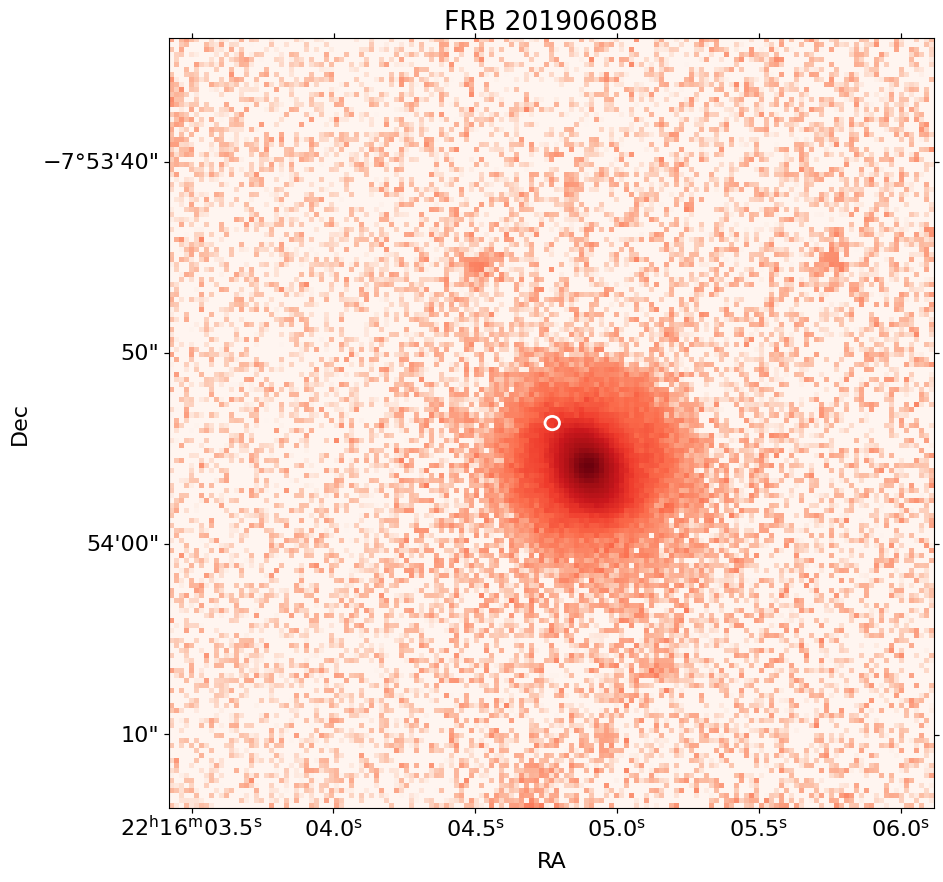

In [17]:
# Can images be downloaded?
imghdu = survey.get_image(imsize=40*u.arcsec, band="r")

# Prepare for visualization
data, header = imghdu.data, imghdu.header
_, med, std = sigma_clipped_stats(data)
norm = vis.ImageNormalize(stretch = vis.LogStretch(), vmin = med, vmax = med + 200*std)
wcs = WCS(header)
ell_aper = SkyEllipticalAperture(frb_coord, a = a_err, b = b_err, theta = pa) 
fig, ax = plt.subplots(1, 1, figsize = (10, 10), subplot_kw={"projection":wcs})

# Visualize
## First the image itself
ax.imshow(data, norm = norm, cmap = "Reds")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("FRB 20190608B")

## Then, the FRB
pix_aper = ell_aper.to_pixel(wcs)
pix_aper.plot(ax, color = "w", lw = 2)

plt.show()


In this case, the host is visually unabiguous. This need not be true all the time, especially if the localization region itself is larger than 1 arcsec. In such cases, a formal framework of assigning probability of a given galaxy being the host is needed. The community standard for this framework is PATH. More details in the subsequent notebook. 